## Proving Causal Impact with Front-Door Math

True ACE (do(X=1) - do(X=0)): 0.2017
Naive Observational ACE (E[Y|X=1] - E[Y|X=0]): -0.0968
Front-Door Adjusted ACE: 0.1663


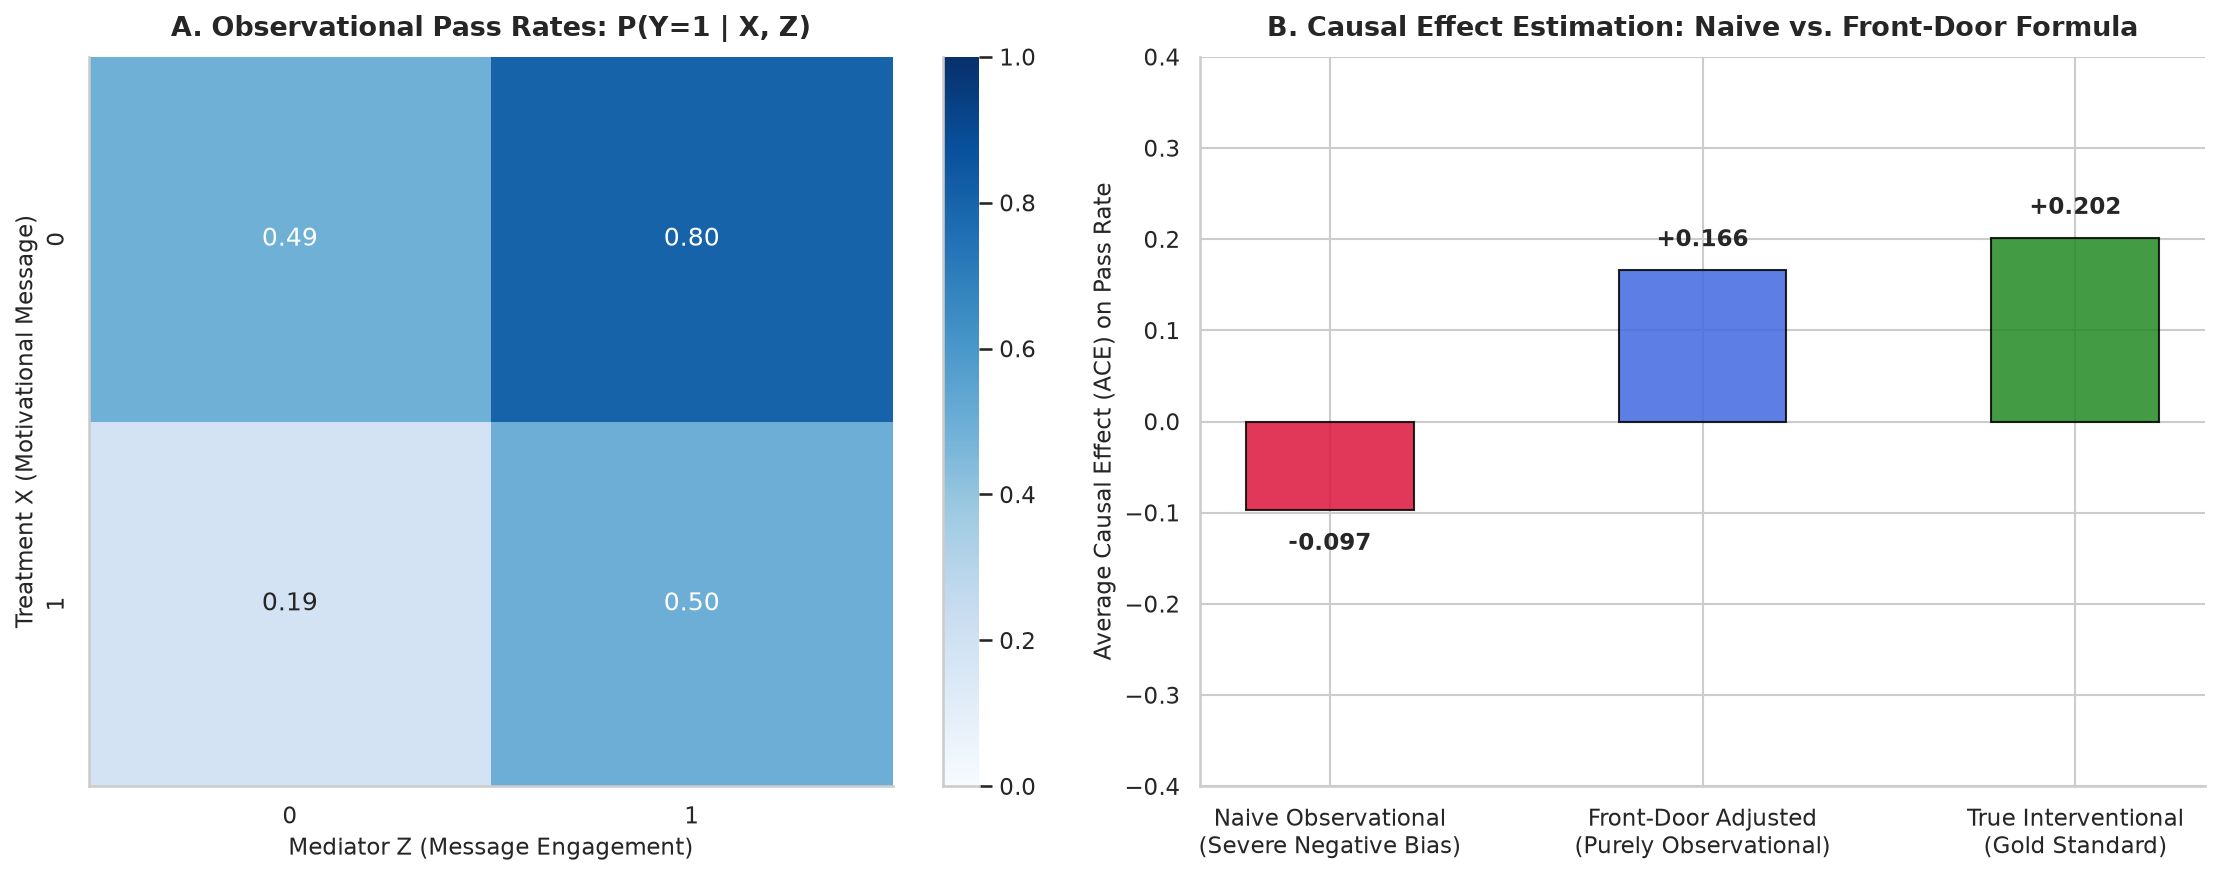

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style='whitegrid', palette='colorblind', font='DejaVu Sans')
plt.rcParams['figure.dpi'] = 150


# 1. Simulate Confounded Binary Educational Platform System (N = 10000)

np.random.seed(42)
N = 10000

# Confounder U: Student's baseline interest/aptitude (1 = High, 0 = Low)
U = np.random.binomial(1, 0.5, N)

# Treatment X: Motivational message sent (1 = Sent, 0 = Not Sent)
# Struggling students (low U) have an 80% chance of getting a message.
X_prob = np.where(U == 1, 0.2, 0.8)
X = np.random.binomial(1, X_prob)

# Mediator Z: Student interacts/opens message (1 = Opened & engaged, 0 = Ignored)
# True mediator caused ONLY by X (no direct arrow from U)
Z_prob = np.where(X == 1, 0.75, 0.10)
Z = np.random.binomial(1, Z_prob)

# Outcome Y: Exam pass rate (1 = Passed, 0 = Failed)
# Passed depends on Z (Message engagement) and U (baseline motivation)
Y_prob = np.clip(0.1 + 0.3 * Z + 0.5 * U, 0.0, 1.0)
Y = np.random.binomial(1, Y_prob)

df_obs = pd.DataFrame({'X': X, 'Z': Z, 'Y': Y, 'U': U})


# 2. Simulate True Interventional Distribution (do-intervention)

U_int = np.random.binomial(1, 0.5, N)

# do(X = 0)
Z0 = np.random.binomial(1, 0.10, N)
Y0_prob = np.clip(0.1 + 0.3 * Z0 + 0.5 * U_int, 0.0, 1.0)
Y0 = np.random.binomial(1, Y0_prob)

# do(X = 1)
Z1 = np.random.binomial(1, 0.75, N)
Y1_prob = np.clip(0.1 + 0.3 * Z1 + 0.5 * U_int, 0.0, 1.0)
Y1 = np.random.binomial(1, Y1_prob)

true_ace = np.mean(Y1) - np.mean(Y0)
print(f"True ACE (do(X=1) - do(X=0)): {true_ace:.4f}")


# 3. Naive Observational Estimate (Biased)

naive_ace = np.mean(df_obs[df_obs['X'] == 1]['Y']) - np.mean(df_obs[df_obs['X'] == 0]['Y'])
print(f"Naive Observational ACE (E[Y|X=1] - E[Y|X=0]): {naive_ace:.4f}")


# 4. Front-Door Adjustment Estimand (Pearl's exact binary formula)

# P(z | x)
def p_z_given_x(z_val, x_val):
    sub = df_obs[df_obs['X'] == x_val]
    return np.mean(sub['Z'] == z_val)

# P(y=1 | x_prime, z)
def p_y_given_x_z(y_val, x_val, z_val):
    sub = df_obs[(df_obs['X'] == x_val) & (df_obs['Z'] == z_val)]
    if len(sub) == 0:
        return 0.0
    return np.mean(sub['Y'] == y_val)

# P(x_prime)
def p_x(x_val):
    return np.mean(df_obs['X'] == x_val)

# Compute E[Y | do(X = x)] = \sum_z P(z | x) \sum_{x'} P(Y=1 | x', z) P(x')
def compute_frontdoor_exp(x_val):
    expected_y = 0.0
    for z in [1]:
        pz_x = p_z_given_x(z, x_val)
        inner_sum = 0.0
        for x_prime in [1]:
            py_xz = p_y_given_x_z(1, x_prime, z)
            px_p = p_x(x_prime)
            inner_sum += py_xz * px_p
        expected_y += pz_x * inner_sum
    return expected_y

fd_e_y_do_x1 = compute_frontdoor_exp(1)
fd_e_y_do_x0 = compute_frontdoor_exp(0)
fd_ace = fd_e_y_do_x1 - fd_e_y_do_x0
print(f"Front-Door Adjusted ACE: {fd_ace:.4f}")


# 5. Plot Results

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Panel A: Visualizing Confounding (Pass Rates by X and Z)
group_means = df_obs.groupby(['X', 'Z'])['Y'].mean().unstack()
sns.heatmap(group_means, annot=True, fmt=".2f", cmap='Blues', cbar=True, ax=ax1, vmin=0, vmax=1)
ax1.set_title("A. Observational Pass Rates: P(Y=1 | X, Z)", fontsize=13, fontweight='bold', pad=10)
ax1.set_xlabel("Mediator Z (Message Engagement)", fontsize=11)
ax1.set_ylabel("Treatment X (Motivational Message)", fontsize=11)

# Panel B: ACE Comparison
bars = ax2.bar(['Naive Observational\n(Severe Negative Bias)', 'Front-Door Adjusted\n(Purely Observational)', 'True Interventional\n(Gold Standard)'], 
               [naive_ace, fd_ace, true_ace], 
               color=['crimson', 'royalblue', 'forestgreen'], alpha=0.85, edgecolor='black', width=0.45)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02 if height >= 0 else height - 0.05, 
             f'{height:+.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)

ax2.set_title("B. Causal Effect Estimation: Naive vs. Front-Door Formula", fontsize=13, fontweight='bold', pad=10)
ax2.set_ylabel("Average Causal Effect (ACE) on Pass Rate", fontsize=11)
ax2.set_ylim(-0.4, 0.4)

sns.despine()
plt.tight_layout()
plt.show()